# Figure4

In [1]:
tag_idx = int(input("INPUT 'visualization_target for Tag RUN_ID'(e.g., 100): "))
print(f'Figure will be drawn based on the run_id_{tag_idx} dataset')

Figure will be drawn based on the run_id_100 dataset


In [2]:
import os 
import numpy as np
import pandas as pd
from datetime import datetime

from setting_for_sda.color_setting import Color_Setting
from setting_for_sda.path_setting import path_list

import lib.stats.stats as st
from lib.utils.statistics import *
from matplotlib import pyplot as plt

from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
from lib.visualization.plot_generator import PlotGen
from lib.topic_modeling.result_prep import Result_Prep as Result_Prep_Topic
from lib.tag_analysis.result_prep import Result_Prep as Result_Prep_Tag
import lib.visualization.figure_setting as figure_setting
from lib.visualization.distribution_collector import (proportion_calc_for_topic, 
                                                      collect_top_bottom_topic, 
                                                      get_distribution_by_list,
                                                      calc_top_bottom_tags_prop)
mpl.rcParams.update(figure_setting.fig_setting)
from lib.utils.datetime_handler import calc_rel_period
import statsmodels.formula.api as smf
from scipy import stats
from adjustText import adjust_text  # pip install adjustText

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

## Load Data

In [3]:
# load for language-level analysis
lang_df = pd.DataFrame()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    rp_tag = Result_Prep_Tag(tag_idx+idx, model_in_run='tag')
    tmp =rp_tag.data_prep()
    tmp = rp_tag.compute_N_by_week(tmp, weight_col='pct', lang = lang)
    lang_df = pd.concat([lang_df, tmp], axis = 0)
    

In [4]:
# load for total-level analysis
tot_df = pd.DataFrame()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    rp_tag = Result_Prep_Tag(tag_idx+idx, model_in_run='tag', lang=lang)
    tmp = rp_tag.get_origin_data()
    tot_df = pd.concat([tot_df, tmp], axis=0)
df_for_tot = tot_df.groupby(['rel_week', 'lang'])['id'].count().reset_index(name='n_docs')

self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/python/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/javascript/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/java/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/c#/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/c++/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/c/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/r/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/php/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/public_for_260105/questions/swift/2020to2025
self.origin_dir :  /mnt/hdd/mghan/so_data_availability/data/publi

In [5]:
df_for_tot.head()

,rel_week,lang,n_docs
0,-104.0,assembly,95
1,-104.0,c,680
2,-104.0,c#,1438
3,-104.0,c++,1123
4,-104.0,dart,334


In [6]:
panel = pd.DataFrame()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    print(f'[Start....] Aggreagate data for {lang} language')
    tmp = load_df(f'/mnt/hdd/mghan/so_data_availability/result/tag/run_id_{100+idx}/data', ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    tmp['language'] = lang
    panel = pd.concat([panel, tmp], axis = 0)
    

[Start....] Aggreagate data for python language
[Start....] Aggreagate data for javascript language
[Start....] Aggreagate data for java language
[Start....] Aggreagate data for c# language
[Start....] Aggreagate data for c++ language
[Start....] Aggreagate data for c language
[Start....] Aggreagate data for r language
[Start....] Aggreagate data for php language
[Start....] Aggreagate data for swift language
[Start....] Aggreagate data for kotlin language
[Start....] Aggreagate data for dart language
[Start....] Aggreagate data for typescript language
[Start....] Aggreagate data for go language
[Start....] Aggreagate data for ruby language
[Start....] Aggreagate data for rust language
[Start....] Aggreagate data for scala language
[Start....] Aggreagate data for julia language
[Start....] Aggreagate data for matlab language
[Start....] Aggreagate data for groovy language
[Start....] Aggreagate data for objective-c language
[Start....] Aggreagate data for vb.net language
[Start....] Ag

In [7]:
panel['rel_week'] = (pd.to_datetime(panel['cdate']) - datetime(2022, 11, 30)).dt.days //7
panel = panel[panel['rel_week']<0].groupby(['language'])['pct'].sum().reset_index().rename(columns = {'pct' : 'post_count'})
panel['log_post_count'] = np.log(panel['post_count'])

In [10]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ---------------------------------------------------------
# 1. 모델 적합 (전체 추세, 언어 무통제)
# ---------------------------------------------------------
d = df_for_tot.copy()
d['t'] = d['rel_week']
d['post'] = (d['t'] >= 0).astype(int)
d['post_t'] = d['post'] * d['t']
TARGET = 'log_n_docs'
d[TARGET] = np.log(d['n_docs'])

m = smf.ols(f'{TARGET} ~ t + post + post_t + C(lang)', data=d).fit(
    cov_type='cluster', cov_kwds={'groups': d['lang']}
)



p_slope = m.pvalues['post_t']

# ---------------------------------------------------------
# 2. counterfactual 기반 관측치별 효과(%) 계산 → t_obs
# ---------------------------------------------------------
cf = d.copy()
cf['post'] = 0
cf['post_t'] = 0
d['y_cf'] = m.predict(cf)
d['eff_pct'] = (np.exp(d[TARGET] - d['y_cf']) - 1) * 100

# t별로 하나씩(지금은 카테고리 없으니 그룹당 row 1개, 그대로 평균 취해도 무방)
t_obs = d.groupby('t').apply(
    lambda g: pd.Series({'eff': np.average(g['eff_pct'])}),
    include_groups=False
).reset_index()

# ---------------------------------------------------------
# 3. 모델 계수 기반 매끈한 추세선 + CI → eff_smooth
# ---------------------------------------------------------
def its_effect(model, t_grid):
    """ITS 효과(%) = exp(β_post + β_post_t*t) - 1, delta method로 CI 계산"""
    β_p, β_pt = model.params['post'], model.params['post_t']
    cov = model.cov_params()
    v_p, v_pt = cov.loc['post', 'post'], cov.loc['post_t', 'post_t']
    c_p_pt = cov.loc['post', 'post_t']

    eff = np.where(t_grid >= 0, β_p + β_pt * t_grid, 0.0)
    var = np.where(t_grid >= 0,
                   v_p + (t_grid**2) * v_pt + 2 * t_grid * c_p_pt, 0.0)
    se = np.sqrt(np.maximum(var, 0))

    return pd.DataFrame({
        't': t_grid,
        'effect_pct': (np.exp(eff) - 1) * 100,
        'ci_low_pct': (np.exp(eff - 1.96 * se) - 1) * 100,
        'ci_high_pct': (np.exp(eff + 1.96 * se) - 1) * 100,
    })

MIN_WEEK, MAX_WEEK = d['t'].min(), d['t'].max()
eff_smooth = its_effect(m, np.arange(MIN_WEEK, MAX_WEEK + 1, 1))


# Prep for analysis

### language level analysis

In [12]:
lang_df["post"]   = (lang_df["rel_week"] >= 0).astype(int)
lang_df["t"]      = lang_df["rel_week"]
lang_df["post_t"] = lang_df["post"] * lang_df["rel_week"]
lang_df["log_n_docs"]  = np.log(lang_df["n_docs"] + 1)


In [13]:
lang_list = ['c',
 'c#',
 'c++',
 'go',
 'java',
 'javascript',
 'kotlin',
 'php',
 'python',
 'r',
 'rust',
 'swift',
 'typescript']

lang_df = lang_df[lang_df['language'].isin(lang_list)].copy()

In [14]:
BIN_SIZE     = 4
MIN_BIN      = -28       # Event Study 범위와 동일
MAX_BIN      = +39

# Bin 범위를 주 단위로 변환
MIN_WEEK = MIN_BIN * BIN_SIZE   # -112
MAX_WEEK = MAX_BIN * BIN_SIZE   # +156

weekly_lang = lang_df.copy()

def beta_to_pct(b): return (np.exp(b) - 1) * 100


its_lang_results = []
formula_lang = f'{TARGET} ~ t + post + post_t'

for lang in sorted(weekly_lang['language'].unique()):
    sub = weekly_lang[weekly_lang['language'] == lang].sort_values('t').copy()
    
    if len(sub) < 30:
        print(f"[SKIP] {lang}: n_obs={len(sub)} < 30")
        continue
    
    try:
        # m = smf.wls(formula_lang, data=sub, weights=sub['n_func']).fit(
        #     cov_type='HAC', cov_kwds={'maxlags': 8}
        # )

        m = smf.wls(formula_lang, data=sub ).fit(
            cov_type='HAC', cov_kwds={'maxlags': 4}
        )
    except Exception as e:
        print(f"[SKIP] {lang}: {e}")
        continue
    
    if m.bse.isna().any():
        print(f"[SKIP] {lang}: NaN SE")
        continue
    

    
    its_lang_results.append({
        'language':         lang,
        'n_func':           weekly_lang[weekly_lang['language'] == lang].shape[0],
        'n_obs':            len(sub),
        
        # Pre-trend
        'pre_trend':        m.params['t'],
        'pre_trend_p':      m.pvalues['t'],
        
        # Level change
        'level_change':     m.params['post'],
        'level_change_se':  m.bse['post'],
        'level_change_p':   m.pvalues['post'],
        'level_change_pct': beta_to_pct(m.params['post']),
        
        # Slope change (가장 중요)
        'slope_change':     m.params['post_t'],
        'slope_change_se':  m.bse['post_t'],
        'slope_change_p':   m.pvalues['post_t'],
        'slope_change_pct': beta_to_pct(m.params['post_t']),
        
        
        'r_squared':        m.rsquared,
    })

its_lang_df = pd.DataFrame(its_lang_results)
its_lang_df = pd.merge(its_lang_df, panel, on = 'language')
its_lang_df['post_count'] = its_lang_df['post_count'].astype(int)


In [15]:


# ── slope change 연 단위 + CI (delta method, post_t의 SE 직접 사용)
its_lang_df['slope_yr_pct']    = (np.exp(its_lang_df['slope_change'] * 52) - 1) * 100
its_lang_df['slope_yr_lo_pct'] = (np.exp((its_lang_df['slope_change'] - 1.96*its_lang_df['slope_change_se']) * 52) - 1) * 100
its_lang_df['slope_yr_hi_pct'] = (np.exp((its_lang_df['slope_change'] + 1.96*its_lang_df['slope_change_se']) * 52) - 1) * 100


# 색: slope change 유의성 기준 (CI가 0 포함 여부와 일치)
def categorize(row):
    if row['slope_change_p'] >= 0.05:
        return figure_setting.PALETTE['neutral']
    return figure_setting.PALETTE['accent'] if row['slope_change'] > 0 else figure_setting.PALETTE['primary']

its_lang_df['color_slope'] = its_lang_df.apply(categorize, axis=1)
its_lang_df['alpha'] = its_lang_df['color_slope'].apply(
    lambda c: 0.55 if c == figure_setting.PALETTE['neutral'] else 1.0)

sorted_s = its_lang_df.sort_values('log_post_count', ascending=True).reset_index(drop=True)

### total level analysis

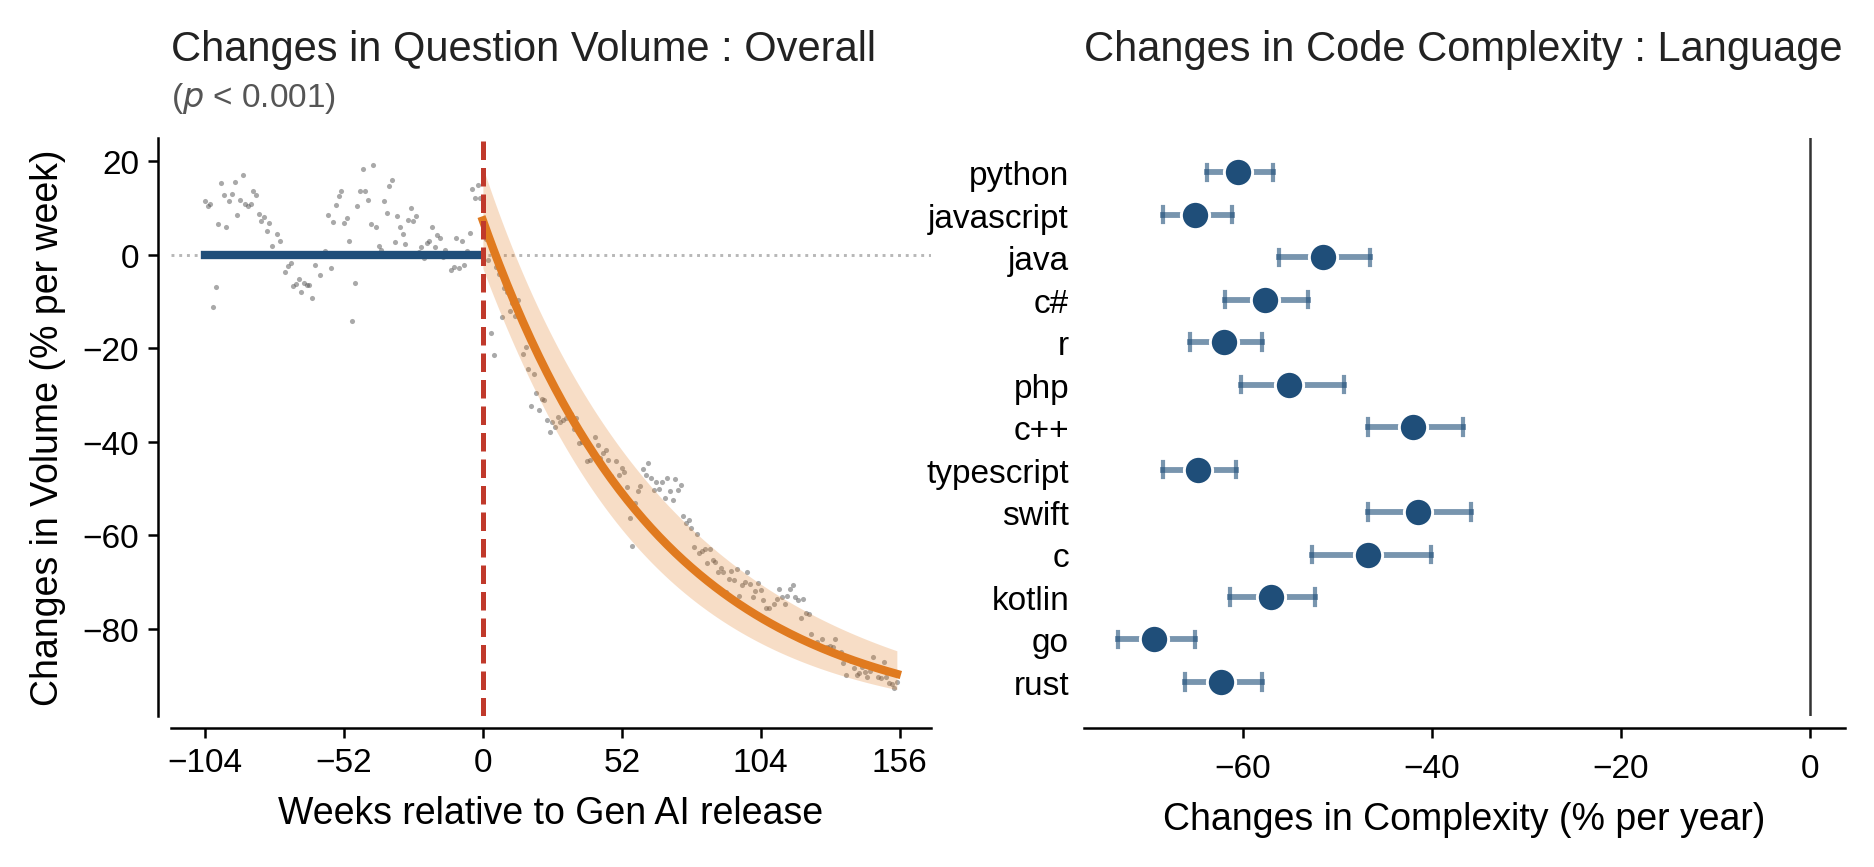

In [16]:
# ---------------------------------------------------------
# 4. 그래프 (기존 코드 그대로 사용 가능)
# ---------------------------------------------------------
fig = plt.figure(figsize=(7.2, 2.5), dpi=300)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])

plotgen = PlotGen()
ax_a.axhline(0, color='#999', lw=0.7, ls=':', alpha=0.7, zorder=0)

x = t_obs['t']
y = t_obs['eff']

plotgen.draw_scatter_plot(ax_a, x, y)
plotgen.draw_line_plot(ax_a,
    eff_smooth.loc[eff_smooth['t'] < 0, 't'],
    eff_smooth.loc[eff_smooth['t'] < 0, 'effect_pct'],
    color=figure_setting.PALETTE['primary'])
plotgen.draw_line_plot(ax_a,
    eff_smooth.loc[eff_smooth['t'] >= 0, 't'],
    eff_smooth.loc[eff_smooth['t'] >= 0, 'effect_pct'],
    color=figure_setting.PALETTE['accent'])
plotgen.fill_confidence_interval(ax_a,
    eff_smooth.loc[eff_smooth['t'] >= 0, 't'],
    eff_smooth.loc[eff_smooth['t'] >= 0, 'ci_low_pct'],
    eff_smooth.loc[eff_smooth['t'] >= 0, 'ci_high_pct'],
    color=figure_setting.PALETTE['accent'])
plotgen.draw_chatgpt_line(ax_a)
plotgen.set_spine_visible(ax_a)
plotgen.set_xticks(ax_a, [-104, -52, 0, 52, 104, 156])
plotgen.set_title_two_lines(ax_a, title_text='Changes in Question Volume : Overall', p_value=float(p_slope))
ax_a.set_xlabel('Weeks relative to Gen AI release')
ax_a.set_ylabel('Changes in Volume (% per week)')

#====================================================================

ax_b.axvline(0, color='#333', lw=0.6, zorder=1)
# ax.axvline(pool_slope_yr, color=figure_setting.PALETTE['event'], lw=0.9, ls='--', zorder=1)

for i, row in sorted_s.iterrows():
    # 95% CI 막대
    ax_b.plot([row['slope_yr_lo_pct'], row['slope_yr_hi_pct']], [i, i],
            color=row['color_slope'], lw=1.4, alpha=row['alpha']*0.6, zorder=2)
    for xe in [row['slope_yr_lo_pct'], row['slope_yr_hi_pct']]:
        ax_b.plot([xe, xe], [i-0.18, i+0.18],
                color=row['color_slope'], lw=1.0, alpha=row['alpha']*0.6, zorder=2)
    # 점추정
    ax_b.scatter(row['slope_yr_pct'], i, s=46,
               facecolor=row['color_slope'], edgecolor='white',
               linewidth=0.7, alpha=row['alpha'], zorder=3)

ax_b.set_yticks(np.arange(len(sorted_s)))
ax_b.set_yticklabels([f"{r['language']}"
                    for _, r in sorted_s.iterrows()])
# ax_b.set_xlabel('Post-ChatGPT slope change (% per year, 95% CI)')

for s in ['top', 'right']: ax_b.spines[s].set_visible(False)
ax_b.spines['left'].set_visible(False)
ax_b.spines['bottom'].set_position(('outward', 3))
ax_b.tick_params(axis='y', length=0)
ax_b.set_xlabel('Changes in Complexity (% per year)')
plotgen.set_title_two_lines(ax_b, title_text='Changes in Code Complexity : Language')

plt.savefig('./fig/Fig4_AB.pdf', bbox_inches='tight', dpi=300)


In [31]:
pd.merge(slope_df, panel, left_on = 'language', right_on = 'language')

,language,slope,se,pct,ci_low,ci_high,p_value,significant,color_slope,alpha,post_count,log_post_count
0,c,-0.013971,0.000802,-1.387356,-1.542215,-1.232254,0.0,True,#1f4e79,1.0,39215.0,10.576815
1,c#,-0.016065,0.000802,-1.593649,-1.748184,-1.438872,0.0,True,#1f4e79,1.0,122905.0,11.719167
2,c++,-0.012282,0.000802,-1.220703,-1.375824,-1.065339,0.0,True,#1f4e79,1.0,74745.0,11.221838
3,go,-0.018574,0.000802,-1.840243,-1.994391,-1.685853,0.0,True,#1f4e79,1.0,13638.0,9.520615
4,java,-0.016530,0.000802,-1.639395,-1.793858,-1.484690,0.0,True,#1f4e79,1.0,149364.0,11.914142
5,javascript,-0.021645,0.000802,-2.141245,-2.294920,-1.987328,0.0,True,#1f4e79,1.0,313204.0,12.654610
6,kotlin,-0.014577,0.000802,-1.447114,-1.601879,-1.292105,0.0,True,#1f4e79,1.0,30644.0,10.330192
7,php,-0.018970,0.000802,-1.879167,-2.033253,-1.724838,0.0,True,#1f4e79,1.0,81188.0,11.304523
8,python,-0.018278,0.000802,-1.811223,-1.965416,-1.656788,0.0,True,#1f4e79,1.0,449184.0,13.015188
9,r,-0.018308,0.000802,-1.814104,-1.968292,-1.659673,0.0,True,#1f4e79,1.0,84618.0,11.345902


log_y ~ t + post + post_t + C(language) + C(language):post + C(language):post_t
baseline: c


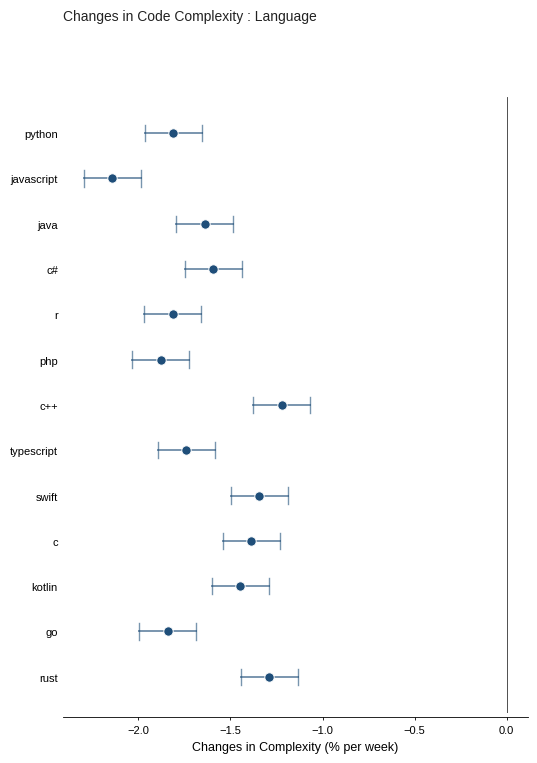

In [32]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import re

# ============================================================
# 1. 데이터 준비
# ============================================================
lang_df["post"]   = (lang_df["rel_week"] >= 0).astype(int)
lang_df["t"]      = lang_df["rel_week"]
lang_df["post_t"] = lang_df["post"] * lang_df["rel_week"]
lang_df["log_y"]  = np.log(lang_df["n_docs"] + 1)

# ============================================================
# 2. 회귀 (전체 pooled, language interaction 포함)
# ============================================================
formula = ("log_y ~ t + post + post_t "
           "+ C(language) + C(language):post + C(language):post_t")
print(formula)

m = smf.ols(formula, data=lang_df).fit(
    cov_type="cluster", cov_kwds={"groups": lang_df["language"]}
)

if m.bse.isna().any():
    print("[WARNING] NaN SE 존재 — 표본 부족 언어 확인 필요")
    print(m.bse[m.bse.isna()])

# ============================================================
# 3. baseline 언어 찾기 + 언어별 slope 계산 (delta method)
# ============================================================
pat_post_t = re.compile(r"C\(language\)\[T\.(.+?)\]:post_t$")
interaction_names = {pat_post_t.match(n).group(1): n
                     for n in m.params.index if pat_post_t.match(n)}

all_langs = list(lang_df["language"].unique())
baseline_lang = [l for l in all_langs if l not in interaction_names][0]
print("baseline:", baseline_lang)

cov = m.cov_params()
rows = []

# baseline 언어: slope = β_post_t 그대로
rows.append({
    "language": baseline_lang,
    "slope": m.params["post_t"],
    "se":    m.bse["post_t"],
})

# 나머지 언어: slope = β_post_t + δ_lang, SE는 delta method
for lang, pname in interaction_names.items():
    beta  = m.params["post_t"]
    delta = m.params[pname]
    slope = beta + delta

    v_beta  = cov.loc["post_t", "post_t"]
    v_delta = cov.loc[pname, pname]
    cov_bd  = cov.loc["post_t", pname]

    var_slope = v_beta + v_delta + 2 * cov_bd
    se_slope  = np.sqrt(max(var_slope, 0))

    rows.append({"language": lang, "slope": slope, "se": se_slope})

slope_df = pd.DataFrame(rows)
slope_df = pd.merge(slope_df, panel, on = 'language')

# ============================================================
# 4. log-scale → 퍼센트 변환 (주간 유지, CI는 log-scale에서 먼저)
# ============================================================
slope_df["pct"]     = (np.exp(slope_df["slope"]) - 1) * 100
slope_df["ci_low"]  = (np.exp(slope_df["slope"] - 1.96*slope_df["se"]) - 1) * 100
slope_df["ci_high"] = (np.exp(slope_df["slope"] + 1.96*slope_df["se"]) - 1) * 100

# ============================================================
# 5. 유의성 / 색상 / 투명도
# ============================================================
slope_df["p_value"]     = 2 * (1 - stats.norm.cdf(np.abs(slope_df["slope"] / slope_df["se"])))
slope_df["significant"] = slope_df["p_value"] < 0.05

slope_df["color_slope"] = np.where(
    slope_df["pct"] < 0,
    figure_setting.PALETTE["primary"],
    figure_setting.PALETTE["accent"]
)
slope_df["alpha"] = np.where(slope_df["significant"], 1.0, 0.35)

# ============================================================
# 6. 정렬
# ============================================================
sorted_s = slope_df.sort_values("log_post_count").reset_index(drop=True)

# ============================================================
# 7. 시각화
# ============================================================
fig, ax_b = plt.subplots(figsize=(6, 8))

ax_b.axvline(0, color='#333', lw=0.6, zorder=1)

for i, row in sorted_s.iterrows():
    # 95% CI 막대
    ax_b.plot([row['ci_low'], row['ci_high']], [i, i],
              color=row['color_slope'], lw=1.4, alpha=row['alpha']*0.6, zorder=2)
    for xe in [row['ci_low'], row['ci_high']]:
        ax_b.plot([xe, xe], [i-0.18, i+0.18],
                  color=row['color_slope'], lw=1.0, alpha=row['alpha']*0.6, zorder=2)
    # 점추정
    ax_b.scatter(row['pct'], i, s=46,
                 facecolor=row['color_slope'], edgecolor='white',
                 linewidth=0.7, alpha=row['alpha'], zorder=3)

ax_b.set_yticks(np.arange(len(sorted_s)))
ax_b.set_yticklabels([f"{r['language']}" for _, r in sorted_s.iterrows()])

for s in ['top', 'right']:
    ax_b.spines[s].set_visible(False)
ax_b.spines['left'].set_visible(False)
ax_b.spines['bottom'].set_position(('outward', 3))
ax_b.tick_params(axis='y', length=0)
ax_b.set_xlabel('Changes in Complexity (% per week)')
plotgen.set_title_two_lines(ax_b, title_text='Changes in Code Complexity : Language')

plt.savefig('./fig/Fig4_AB.pdf', bbox_inches='tight', dpi=300)

log_y ~ t + post + post_t + C(language) + C(language):post + C(language):post_t
baseline: c


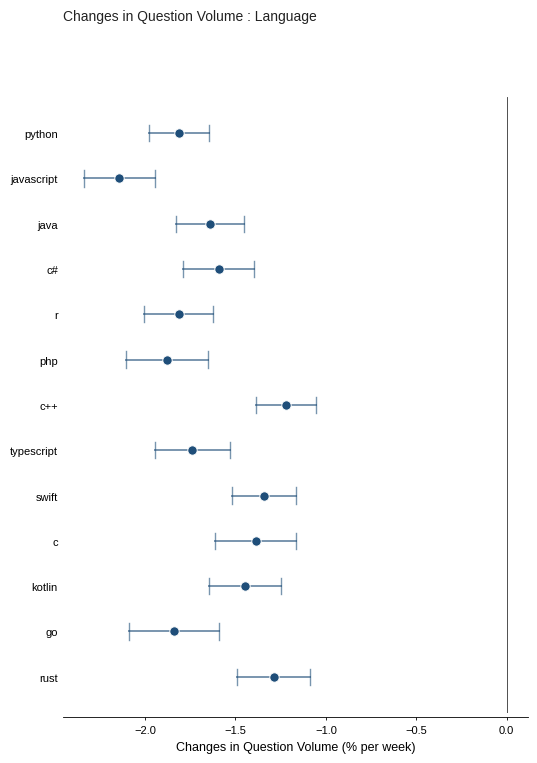

In [33]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import re

# ============================================================
# 1. 데이터 준비
# ============================================================
lang_df["post"]   = (lang_df["rel_week"] >= 0).astype(int)
lang_df["t"]      = lang_df["rel_week"]
lang_df["post_t"] = lang_df["post"] * lang_df["rel_week"]
lang_df["log_y"]  = np.log(lang_df["n_docs"] + 1)

# ============================================================
# 2. 회귀 (전체 pooled, language interaction 포함) — 점추정치용
# ============================================================
formula = ("log_y ~ t + post + post_t "
           "+ C(language) + C(language):post + C(language):post_t")
print(formula)

m = smf.ols(formula, data=lang_df).fit(
    cov_type="cluster", cov_kwds={"groups": lang_df["language"]}
)

if m.bse.isna().any():
    print("[WARNING] NaN SE 존재 — 표본 부족 언어 확인 필요")
    print(m.bse[m.bse.isna()])

# ============================================================
# 3. baseline 언어 찾기 + 언어별 slope(점추정치만) 계산
# ============================================================
pat_post_t = re.compile(r"C\(language\)\[T\.(.+?)\]:post_t$")
interaction_names = {pat_post_t.match(n).group(1): n
                     for n in m.params.index if pat_post_t.match(n)}

all_langs = list(lang_df["language"].unique())
baseline_lang = [l for l in all_langs if l not in interaction_names][0]
print("baseline:", baseline_lang)

rows = []
rows.append({"language": baseline_lang, "slope": m.params["post_t"]})
for lang, pname in interaction_names.items():
    slope = m.params["post_t"] + m.params[pname]
    rows.append({"language": lang, "slope": slope})

slope_df = pd.DataFrame(rows)
slope_df = pd.merge(slope_df, panel, on="language")

# ============================================================
# 4. 언어별 개별 회귀(HAC)로 SE 계산
# ============================================================
se_from_individual = {}
for lang in lang_df["language"].unique():
    sub = lang_df[lang_df["language"] == lang].sort_values("t").copy()
    if len(sub) < 30:
        print(f"[SKIP] {lang}: n_obs={len(sub)} < 30")
        continue
    m_ind = smf.ols("log_y ~ t + post + post_t", data=sub).fit(
        cov_type="HAC", cov_kwds={"maxlags": 4}
    )
    se_from_individual[lang] = m_ind.bse["post_t"]

slope_df["se"] = slope_df["language"].map(se_from_individual)

missing = slope_df[slope_df["se"].isna()]
if len(missing) > 0:
    print("[WARNING] HAC SE 없음(표본 부족 등):", missing["language"].tolist())
slope_df = slope_df.dropna(subset=["se"]).copy()

# ============================================================
# 5. log-scale → 퍼센트 변환 (주간 유지, CI는 log-scale에서 먼저)
# ============================================================
slope_df["pct"]     = (np.exp(slope_df["slope"]) - 1) * 100
slope_df["ci_low"]  = (np.exp(slope_df["slope"] - 1.96*slope_df["se"]) - 1) * 100
slope_df["ci_high"] = (np.exp(slope_df["slope"] + 1.96*slope_df["se"]) - 1) * 100

# ============================================================
# 6. 유의성 / 색상 / 투명도 (비유의 = 회색)
# ============================================================
slope_df["p_value"]     = 2 * (1 - stats.norm.cdf(np.abs(slope_df["slope"] / slope_df["se"])))
slope_df["significant"] = slope_df["p_value"] < 0.05

def get_color(row):
    if not row["significant"]:
        return "#999999"
    elif row["pct"] > 0:
        return figure_setting.PALETTE["accent"]
    else:
        return figure_setting.PALETTE["primary"]

slope_df["color_slope"] = slope_df.apply(get_color, axis=1)
slope_df["alpha"] = 1.0

# ============================================================
# 7. 정렬 (기존과 동일, log_post_count 기준)
# ============================================================
sorted_s = slope_df.sort_values("log_post_count").reset_index(drop=True)

# ============================================================
# 8. 시각화
# ============================================================
fig, ax_b = plt.subplots(figsize=(6, 8))

ax_b.axvline(0, color='#333', lw=0.6, zorder=1)

for i, row in sorted_s.iterrows():
    ax_b.plot([row['ci_low'], row['ci_high']], [i, i],
              color=row['color_slope'], lw=1.4, alpha=row['alpha']*0.6, zorder=2)
    for xe in [row['ci_low'], row['ci_high']]:
        ax_b.plot([xe, xe], [i-0.18, i+0.18],
                  color=row['color_slope'], lw=1.0, alpha=row['alpha']*0.6, zorder=2)
    ax_b.scatter(row['pct'], i, s=46,
                 facecolor=row['color_slope'], edgecolor='white',
                 linewidth=0.7, alpha=row['alpha'], zorder=3)

ax_b.set_yticks(np.arange(len(sorted_s)))
ax_b.set_yticklabels([f"{r['language']}" for _, r in sorted_s.iterrows()])

for s in ['top', 'right']:
    ax_b.spines[s].set_visible(False)
ax_b.spines['left'].set_visible(False)
ax_b.spines['bottom'].set_position(('outward', 3))
ax_b.tick_params(axis='y', length=0)
ax_b.set_xlabel('Changes in Question Volume (% per week)')
plotgen.set_title_two_lines(ax_b, title_text='Changes in Question Volume : Language')

plt.savefig('./fig/FigX_lang_questionvolume.pdf', bbox_inches='tight', dpi=300)

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt

# ============================================================
# 1. 언어별 개별 회귀(HAC)로 SE 계산
# ============================================================
se_from_individual = {}
for lang in lang_df['language'].unique():
    sub = lang_df[lang_df['language'] == lang].sort_values('t').copy()
    if len(sub) < 30:
        print(f"[SKIP] {lang}: n_obs={len(sub)} < 30")
        continue
    m_ind = smf.ols('log_cc_mean ~ t + post + post_t', data=sub).fit(
        cov_type='HAC', cov_kwds={'maxlags': 4}
    )
    se_from_individual[lang] = m_ind.bse['post_t']

slope_df['se_hac'] = slope_df['language'].map(se_from_individual)

# HAC SE를 못 구한 언어(표본 부족 등)는 걸러내기
missing = slope_df[slope_df['se_hac'].isna()]
if len(missing) > 0:
    print("[WARNING] HAC SE 없음(표본 부족 등):", missing['language'].tolist())
plot_df = slope_df.dropna(subset=['se_hac']).copy()

# ============================================================
# 2. CI / p-value / 유의성 (HAC 기준으로 재계산)
# ============================================================
plot_df['ci_low']  = (np.exp(plot_df['slope'] - 1.96*plot_df['se_hac']) - 1) * 100
plot_df['ci_high'] = (np.exp(plot_df['slope'] + 1.96*plot_df['se_hac']) - 1) * 100
plot_df['p_value'] = 2 * (1 - stats.norm.cdf(np.abs(plot_df['slope'] / plot_df['se_hac'])))
plot_df['significant'] = plot_df['p_value'] < 0.05

# ============================================================
# 3. 색상 (비유의 = 회색, 유의 & 증가 = accent, 유의 & 감소 = primary)
# ============================================================
def get_color(row):
    if not row['significant']:
        return '#999999'
    elif row['pct'] > 0:
        return figure_setting.PALETTE['accent']
    else:
        return figure_setting.PALETTE['primary']

plot_df['color_slope'] = plot_df.apply(get_color, axis=1)
plot_df['alpha'] = 1.0

# ============================================================
# 4. 정렬
# ============================================================
sorted_s = plot_df.sort_values('pct').reset_index(drop=True)

# ============================================================
# 5. 시각화
# ============================================================
fig, ax_b = plt.subplots(figsize=(6, 8))

ax_b.axvline(0, color='#333', lw=0.6, zorder=1)

for i, row in sorted_s.iterrows():
    ax_b.plot([row['ci_low'], row['ci_high']], [i, i],
              color=row['color_slope'], lw=1.4, alpha=row['alpha']*0.6, zorder=2)
    for xe in [row['ci_low'], row['ci_high']]:
        ax_b.plot([xe, xe], [i-0.18, i+0.18],
                  color=row['color_slope'], lw=1.0, alpha=row['alpha']*0.6, zorder=2)
    ax_b.scatter(row['pct'], i, s=46,
                 facecolor=row['color_slope'], edgecolor='white',
                 linewidth=0.7, alpha=row['alpha'], zorder=3)

ax_b.set_yticks(np.arange(len(sorted_s)))
ax_b.set_yticklabels([f"{r['language']}" for _, r in sorted_s.iterrows()])

for s in ['top', 'right']:
    ax_b.spines[s].set_visible(False)
ax_b.spines['left'].set_visible(False)
ax_b.spines['bottom'].set_position(('outward', 3))
ax_b.tick_params(axis='y', length=0)
ax_b.set_xlabel('Changes in Complexity (% per week)')
plotgen.set_title_two_lines(ax_b, title_text='Changes in Code Complexity : Language')

plt.savefig('./fig/Fig4_AB.pdf', bbox_inches='tight', dpi=300)